<center>
<img src="https://raw.githubusercontent.com/dvgodoy/PyTorch101_ODSC_Europe2020/master/images/linear_dogs.jpg" height="200">

# Семинар 1: введение в PyTorch
</center>

В этом семинаре мы познакомимся с библиотекой [PyTorch.](https://pytorch.org/docs/stable/index.html) Она будет основной на нашем курсе.

На сегоняшний день PyTorch —  это один из самых поплуярных фреймворков для глубинного обучения. На нём пишут большую часть кода, связанного с нейросетями. Так получилось из-за того, что с ним очень удобно работать. Он очень похож на Numpy, его удодбно использовать с GPU, а ещё он умеет считать градиенты за вас.

Концепция библиотеки pytorch — расширить функционал numpy, добавив туда возможность автоматического расчёта градиентов произвольных функций и их композиций, стараясь максимально сохранить привычную семантику.

Устанавливаем библиотеку

```
pip install torch torchvision
```

Дополнительно с торчом выходят `torchvision` и `torchaudio`. В них есть куча разных методов для работы с изображениями и звуком. Обе эти библиотеки тоже можно поставить виесте с торчом. Первая из них уже сегодня нам понадобится.

In [2]:
! pip install torch torchvision torchaudio

In [3]:
import numpy as np
np.__version__

'2.4.2'

In [4]:
import torch
torch.__version__

'2.10.0+cpu'

In [5]:
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 1. Тензоры и базовые операции над ними

Базовой единицей фреймворка является структура, которая называется `torch.Tensor`. Tensor - это аналог `numpy.array`, многие методы работы с `torch.Tensor` в точности повторяют методы `numpy array`.

Тензор — это тот тип данных, с которыми работают все нейросети в PyTorch. Матрицы весов — это тензоры. Данные, которые мы подаем на вход сети тоже обязательно должны быть приведены к типу `torch.Tensor`. Ну и выход сети, разумеется, тоже будет иметь тип `torch.Tensor`.

Посмотрим на способы создать тензоры.

In [6]:
# можно создать тензор из листа
x = torch.tensor([1, 2, 3, 4])
x

tensor([1, 2, 3, 4])

In [7]:
# или кортежа tuple
b = ((1, 2, 3), (4, 5, 6))
t = torch.tensor(b)
t

tensor([[1, 2, 3],
        [4, 5, 6]])

In [8]:
# или из скаляра
torch.tensor(42)

tensor(42)

In [9]:
torch.tensor(3.145)

tensor(3.1450)

In [10]:
torch.tensor(True)

tensor(True)

In [11]:
# или из массива numpy
a = np.array([[1, 2], [3, 4]])
t = torch.tensor(a)
t

tensor([[1, 2],
        [3, 4]])

Строки (str), словари (dict), списки строк — нельзя напрямую конвертировать в тензор

In [12]:
# можно посмотреть тип данных, упакованных в тензор
x.dtype

torch.int64

In [13]:
# можно задать тензор из нулей
torch.zeros(3, 4)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [14]:
# или из единиц, но уже более сложной размерности
torch.ones(3, 4, 2)

tensor([[[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]]])

In [15]:
torch.ones(4, 2)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [16]:
torch.ones(2)

tensor([1., 1.])

In [17]:
# можно сгенерировать тензор из стандартного нормального распределения
torch.randn(2,2)

tensor([[ 1.4717,  1.6631],
        [-0.4306, -1.7460]])

In [18]:
# тензор с нулями и указанием типа данных
x = torch.zeros(5, 3, dtype=torch.double)
print(x)

x = torch.zeros((5, 3), dtype=torch.int)
print(x)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)
tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], dtype=torch.int32)


In [19]:
x.double() # можно поменяить тип данных

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)

In [20]:
x.int()

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], dtype=torch.int32)

In [21]:
# float32 базовый тип данных и не подписывается в выдаче
x.float()

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

Все срезы, операции, размерности работают как в numpy. Более того, разработчики PyTorch в последних версиях библиотеки инвестировали массу усилий, чтобы сделать названия функций похожими на numpy. Благодаря этому, если вы знаете одну библиотеку, вы легко можете работать и с другой. Тем не менее, название части функций различается.

In [22]:
x

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], dtype=torch.int32)

In [23]:
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
x

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [24]:
# первая строка
x[0]

tensor([1, 2, 3])

In [25]:
# все строки первого столбца
x[:,1]

tensor([2, 5, 8])

In [26]:
x + 10

tensor([[11, 12, 13],
        [14, 15, 16],
        [17, 18, 19]])

In [27]:
torch.exp(x)

tensor([[2.7183e+00, 7.3891e+00, 2.0086e+01],
        [5.4598e+01, 1.4841e+02, 4.0343e+02],
        [1.0966e+03, 2.9810e+03, 8.1031e+03]])

In [28]:
x[x > 3]

tensor([4, 5, 6, 7, 8, 9])

In [29]:
x[x >= 3]

tensor([3, 4, 5, 6, 7, 8, 9])

In [30]:
# если хотим сохранить структуру
y1 = torch.tensor([[0, -1], [3, -4]])
y2 = torch.where(y1 >= 0, y1, y1 * 10)
y2

tensor([[  0, -10],
        [  3, -40]])

In [31]:
y = torch.randn(5, 3)
y

tensor([[-0.1280, -0.8279, -0.2881],
        [-0.0279,  1.0103, -0.3300],
        [ 0.7342, -0.4103, -1.5528],
        [ 0.4591,  0.1641, -0.7607],
        [ 0.3116, -0.3338,  0.5477]])

In [32]:
x = torch.randn(5, 3)
x

tensor([[-1.1004, -1.4222, -1.6800],
        [-0.1976,  0.8329, -1.6362],
        [-0.8678, -0.9701, -0.1158],
        [ 0.2523,  0.5510,  1.1463],
        [-1.3851,  0.2181, -0.5591]])

In [33]:
x + y # поэлементное сложение

tensor([[-1.2284, -2.2501, -1.9680],
        [-0.2255,  1.8432, -1.9661],
        [-0.1336, -1.3804, -1.6686],
        [ 0.7114,  0.7151,  0.3856],
        [-1.0734, -0.1158, -0.0114]])

In [34]:
x * y # поэлементное умножение

tensor([[ 0.1409,  1.1775,  0.4839],
        [ 0.0055,  0.8415,  0.5399],
        [-0.6371,  0.3981,  0.1798],
        [ 0.1158,  0.0904, -0.8720],
        [-0.4316, -0.0728, -0.3062]])

In [35]:
print(
    x.shape,
    y.T.shape
)

torch.Size([5, 3]) torch.Size([3, 5])


In [36]:
 # матричное умножение
x @ y.T

tensor([[ 1.8023, -0.8518,  2.3844,  0.5394, -0.7884],
        [-0.1930,  1.3869,  2.0539,  1.2906, -1.2358],
        [ 0.9477, -0.9177, -0.0593, -0.4695, -0.0100],
        [-0.8187,  0.1714, -1.8209, -0.6658,  0.5226],
        [ 0.1578,  0.4434, -0.2382, -0.1748, -0.8107]])

In [37]:
x.dtype, y.dtype # матрицы разного типа и умножение упало

(torch.float32, torch.float32)

In [38]:
x.float() @ y.T

tensor([[ 1.8023, -0.8518,  2.3844,  0.5394, -0.7884],
        [-0.1930,  1.3869,  2.0539,  1.2906, -1.2358],
        [ 0.9477, -0.9177, -0.0593, -0.4695, -0.0100],
        [-0.8187,  0.1714, -1.8209, -0.6658,  0.5226],
        [ 0.1578,  0.4434, -0.2382, -0.1748, -0.8107]])

In [39]:
x

tensor([[-1.1004, -1.4222, -1.6800],
        [-0.1976,  0.8329, -1.6362],
        [-0.8678, -0.9701, -0.1158],
        [ 0.2523,  0.5510,  1.1463],
        [-1.3851,  0.2181, -0.5591]])

In [40]:
# добавили измерение в начало
x.unsqueeze(0).shape

torch.Size([1, 5, 3])

In [41]:
x.unsqueeze(0)

tensor([[[-1.1004, -1.4222, -1.6800],
         [-0.1976,  0.8329, -1.6362],
         [-0.8678, -0.9701, -0.1158],
         [ 0.2523,  0.5510,  1.1463],
         [-1.3851,  0.2181, -0.5591]]])

In [42]:
# убрали измерение в начале
x.unsqueeze(0).squeeze(0).shape

torch.Size([5, 3])

In [43]:
x.unsqueeze(0).squeeze(0)

tensor([[-1.1004, -1.4222, -1.6800],
        [-0.1976,  0.8329, -1.6362],
        [-0.8678, -0.9701, -0.1158],
        [ 0.2523,  0.5510,  1.1463],
        [-1.3851,  0.2181, -0.5591]])

Мы также можем переводить тензоры назад в numpy или в питоновские листы:

In [44]:
x.numpy()

array([[-1.1004167 , -1.4221613 , -1.6799798 ],
       [-0.19758166,  0.83286965, -1.6361552 ],
       [-0.86781144, -0.97012055, -0.11579204],
       [ 0.25228536,  0.55097765,  1.146333  ],
       [-1.3850533 ,  0.21808179, -0.55909854]], dtype=float32)

Если у тензора считаются градиенты, до перевода его нужно "снять" с графа вычислений

In [45]:
t = torch.ones(3, requires_grad=True)
arr = t.detach().numpy()  # требуется detach(), иначе будет ошибка
arr

array([1., 1., 1.], dtype=float32)

In [46]:
x

tensor([[-1.1004, -1.4222, -1.6800],
        [-0.1976,  0.8329, -1.6362],
        [-0.8678, -0.9701, -0.1158],
        [ 0.2523,  0.5510,  1.1463],
        [-1.3851,  0.2181, -0.5591]])

In [47]:
x.tolist()

[[-1.100416660308838, -1.422161340713501, -1.6799798011779785],
 [-0.19758166372776031, 0.8328696489334106, -1.6361552476882935],
 [-0.8678114414215088, -0.9701205492019653, -0.11579203605651855],
 [0.252285361289978, 0.5509776473045349, 1.1463329792022705],
 [-1.385053277015686, 0.2180817872285843, -0.5590985417366028]]

Одномерные тензоры можно распаковать в числа

In [48]:
x = torch.tensor([3])
x # тензор размера 1x1

tensor([3])

In [49]:
x.item() # число

3

### Задание 1:

- При помощи numpy посчитайте сумму квадратов чисел от 1 до 10000
- Сделайте то же самое с помощью pytorch

In [50]:
ans = 0
for i in range(1, 10_001):
    ans += i**2
print('basic result:', ans)

basic result: 333383335000


In [51]:
# ваш код  ¯\_(⊙︿⊙)_/¯
print('numpy result:', (np.arange(1, 10001) ** 2).sum())


numpy result: 333383335000


In [52]:
print('torch result:', (torch.arange(1, 10_001) ** 2).sum().item())

torch result: 333383335000


### Задание 2:

Реализуйте на PyTorch сигмоиду

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

In [53]:
# ващ код  ¯\_(⊙︿⊙)_/¯
def sigmoid(x: torch.Tensor):
    return 1 / (1 + torch.exp(x))

In [54]:
torch.tensor(0)

tensor(0)

### Задание 3:

Реализуйте на PyTorch среднюю квадратичную ошибку.

$$
MSE(\hat y, y) = \frac{1}{n} \cdot \sum_{i=1}^n (\hat y - y)^2
$$

In [55]:
# ващ код  ¯\_(⊙︿⊙)_/¯
def mse(y_pred, y):
    return 1 / len(y) * ((y_pred - y) ** 2).sum()

# 2. Работа с GPU

Первое ключевое отличие PyTorch от numpy - лёгкая работа с GPU.

Давайте откроем эту терадку в Google Colab и запустим её на видео-карте. Это можно сделать кнопкой `Среда выполнения/сменить среду выполнения`. В списке выберите любую доступную видеокарту.

In [56]:
!nvidia-smi

"nvidia-smi" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [57]:
x = torch.randn(3, 5)
x.dtype, x.device # тензор лежит на CPU

(torch.float32, device(type='cpu'))

In [58]:
# проверяем доступность GPU
torch.cuda.is_available()

False

In [59]:
torch.cuda.device_count() # число доступных GPU

0

In [60]:
# чтобы отправить вычисления на девайс,
# надо создать переменную с ним
# число - номер видокарты в компе
torch.device('cuda:0')

device(type='cuda', index=0)

In [61]:
# универсальная строка которую мы будем втыкать во все наши скрипты
# выбирает то что есть
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [62]:
x = torch.randn(4, 4)

x.to(device) # отправить тензор на GPU

tensor([[-0.7331, -1.3710, -1.4331,  0.6329],
        [ 0.2705, -0.4388,  1.8151, -1.2450],
        [ 2.1526, -0.6701, -2.1275, -0.7404],
        [ 0.8647,  0.5160, -1.8725,  0.8376]])

In [ ]:
# x.cuda() # ещё можно отправить так

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
x.cpu() # вернуть назад

tensor([[ 0.5674, -1.0031,  0.7766, -1.6683],
        [-0.6176,  0.6048, -0.5770, -0.8122],
        [ 0.9493,  0.0309, -0.0079,  0.6131],
        [ 0.4739, -1.3424,  0.6659, -0.8984]])

Обратите внимание, что при изменении device (c GPU на CPU и обратно происходит копирование). Операции между тензорами на разных устройствах не возможны:

ps это супер-важное замечание, ошибка такого типа будет часто всплывать при обучении моделей

In [ ]:
x.cuda() + x

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

Сравним скорость работы типичного слоя нейронной сети - матричное умножение + нелинейность на CPU и GPU



In [ ]:
def layer(A, B):
    C = A @ B
    C = C ** 2
    return C

In [ ]:
A = torch.randn(1000, 1000)
B = torch.randn(1000, 1000)

- µs (микросекунда) = 10⁻⁶ секунды
- ms (миллисекунда) = 10⁻³ секунды

In [ ]:
%timeit _ = layer(A, B)

4.26 ms ± 45.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
A_device, B_device = A.to(device), B.to(device)
%timeit _ = layer(A_device, B_device)

572 µs ± 11.6 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Видим, что вычисления на GPU значительно быстрее вычислений на CPU, но мы не учли одну вещь - время копирования данных. Давайте сделаем более честный замер

In [ ]:
%timeit _ = layer(A.to(device), B.to(device))

6.09 ms ± 461 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Всё ещё выигрываем во времени, но копирование сожрало часть выигрыша.

На GPU делаются сложные вычисления. Все простые операции вроде подготовки данных и логгирования метрик должны происходить на CPU.

Данные обычно предобрабатывают на CPU, затем формируют батчи для обучения и передают на GPU. Сама нейросеть учится на GPU и там хранит свои градиенты и веса.

# 3. Производные да градиенты

Вторая ключевая особенность PyTorch - умение считать градиенты. При создании тензора можно указать, нужно ли считать по нему градиент с помощью параметра `requires_grad`.

Когда `requires_grad=True` мы сообщаем фреймворку, что хотим считать градиенты по этому тензору. Иными словами, у любого тензора, у которого указан данный параметр, будет доступ к цепочке операций и преобразований совершенными с ними. Если эти функции дифференцируемые, то у тензора появляется параметр `.grad`, в котором хранится значение градиента.

PyTorch проходит по всем операциям, которые фигурируют в графе вычислений, и применяет к ним производную сложной функции (на английском пафосно называют это chain rule):

$$ {\partial f(g(x)) \over \partial x} = {\partial f(g(x)) \over \partial g(x)}\cdot {\partial g(x) \over \partial x} $$

Давайте попробуем!

In [64]:
x = torch.randn(3, 3, requires_grad=True)
x

tensor([[-1.3838,  0.1953,  1.7319],
        [-0.9073, -1.8084, -1.1535],
        [-0.7341, -0.2959,  1.1175]], requires_grad=True)

In [65]:
# пока градиента нет
print(x.grad, '<- gradient')

None <- gradient


In [66]:
y = torch.sum(x * x)
y.backward()

# градиент подъехал
print(x.grad, '<- gradient')

tensor([[-2.7677,  0.3907,  3.4638],
        [-1.8147, -3.6169, -2.3071],
        [-1.4683, -0.5917,  2.2349]]) <- gradient


Если не предпринимать никаких дополнительных действий, то множественный вызов `.backward()` будет не перезаписывать градиенты тензоров, а складывать их с уже существующим значением (сам граф вычислений каждый раз разрушается).

In [67]:
z = torch.sum(2 * x)
z.backward()

# Заметьте, что ко всем значениям прибавилось 2
print(x.grad, '<- gradient')

tensor([[-0.7677,  2.3907,  5.4638],
        [ 0.1853, -1.6169, -0.3071],
        [ 0.5317,  1.4083,  4.2349]]) <- gradient


Обычно мы обучаем модель не по одному объекту, а на большой выборке. Вся выборка в память не влезает. Мы прогоняем через нейросеть данные батчами. PyTorch позволяет накапливать градиенты по батчам не помещая в память все данные.

Чтобы считать градиент с нуля, достаточно его удалить или обнулить.

In [68]:
x.grad.zero_()

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [69]:
x.grad

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

### Задание 4:

Реализуйте расчёт градиента для функции

$$
f(w) = \prod_{i,j} \ln(\ln(w_{ij} + 7)
$$

в точке `w = [[5,10], [1,2]]`

In [70]:
# ващ код  ¯\_(⊙︿⊙)_/¯
w = torch.tensor([[5, 10], [1, 2]], requires_grad=True, dtype=torch.float)
f = torch.prod(torch.log((torch.log(w + 7))))
f.backward()
print(w.grad)

tensor([[0.0201, 0.0109],
        [0.0449, 0.0351]])


В numpy существует интуитивно понятная функция `.copy()`, но в pytorch функции с таким названием нет! Это связано с тем, что тензоры в pytorch привязаны к графу вычислений, который надо также учитывать при копировании.

`.clone()` копирует тензор и сохраняет его привязку к текущему дереву вычислений.

### Задание 5:

Что будет в переменной `x` в результате выполнения следующего кода? Почему?

In [71]:
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
y = x
y[2] = torch.ones(3)

print(y)
print('')
print(x)

tensor([[1, 2, 3],
        [4, 5, 6],
        [1, 1, 1]])

tensor([[1, 2, 3],
        [4, 5, 6],
        [1, 1, 1]])


Как это можно исправить?

In [72]:
# ващ код  ¯\_(⊙︿⊙)_/¯
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
y = x.clone()
y[2] = torch.ones(3)

print(y)
print('')
print(x)

tensor([[1, 2, 3],
        [4, 5, 6],
        [1, 1, 1]])

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])


Очень часто при копировании градиентов недостаточно сделать только `.clone`, так как мы не хотим сохранять связь с графом вычислений. Например, если мы применим `.clone` к выходу нейросети, то добавим новое ребро в граф вычислений, что повличет накладные расходы.

Чтобы отвязать тензор от текущего графа вычислений надо использовать `.detach()`, он копирует лишь значения элементов тензора, отвязывая его от текущего графа вычислений.


In [73]:
x = torch.rand(3, requires_grad=True)
x.requires_grad

True

In [74]:
y = x.clone()
y.requires_grad

True

In [75]:
z = x.detach()
z.requires_grad

False

### Забавный пример: как положить продакшн?

Когда мы будем учить нейросети, мы будем делать много итераций обучения. В конце каждой мы захотим сохранять значение функции потерь. Если вычислить её для нового батча данных и забыть отвязать от графа вычислений, мы будем таскать за собой весь граф. Давайте искусттвенно забудем это сделать и уроним GPU по памяти.

In [ ]:
torch.cuda.empty_cache() # на всякий случай почистили кэш

w = torch.randn(10000, requires_grad=True) #.cuda() # наши веса модели

losses = [ ]
for i in range(10):
    x = torch.randn((10000, 10000))# .cuda()  # пришли свежие данные
    loss = torch.linalg.norm(x @ w)         # как бы посчитали метрику качества
    losses.append(loss)                     # запомнили её

    print(f"Сейчас занято {torch.cuda.max_memory_allocated() // 1024 // 1024} MB")

Сейчас занято 0 MB
Сейчас занято 0 MB
Сейчас занято 0 MB
Сейчас занято 0 MB
Сейчас занято 0 MB
Сейчас занято 0 MB
Сейчас занято 0 MB
Сейчас занято 0 MB
Сейчас занято 0 MB
Сейчас занято 0 MB


Отвязать от графа вычислений скаляр можно методом `.item()`. Добавляем его к коду и проблема уходит.

In [ ]:
torch.cuda.empty_cache() # на всякий случай почистили кэш

w = torch.randn(10000, requires_grad=True).cuda() # наши веса модели

losses = [ ]
for i in range(50):
    x = torch.randn((10000, 10000)).cuda()  # пришли свежие данные
    loss = torch.linalg.norm(x @ w)         # как бы посчитали метрику качества
    losses.append(loss.item())              # запомнили её

    print(f"Сейчас занято {torch.cuda.max_memory_allocated() // 1024 // 1024} MB")

# 4. Оптимизация

Итак, PyTorch умеет искать производные, осталось научиться применять его для оптимизации.

Давайте обучим линейную регрессию.

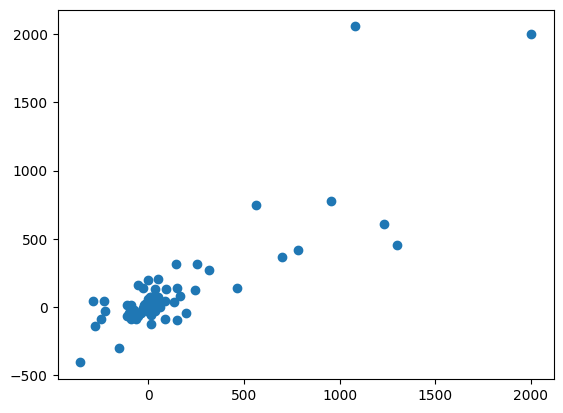

In [76]:
# data_url = "http://lib.stat.cmu.edu/datasets/boston"
# raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
# data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
# target = raw_df.values[1::2, 2]

# plt.scatter(data[:, -1], target);


raw_df = pd.read_csv("../../homeworks/yearpredictionmsd.zip")
data = raw_df.iloc[5]
target = raw_df.iloc[0]

plt.scatter(data, target)

Зададим тензоры для весов. Обучим модель на CPU, чтобы не загромождать код перебрасыванием данных туда-сюда.



In [77]:
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [78]:
w, b

(tensor([0.2606], requires_grad=True), tensor([-1.6180], requires_grad=True))

In [79]:
# x = torch.tensor(data[:, -1] / data[:, -1].max(), dtype=torch.float32)
# y = torch.tensor(target, dtype=torch.float32)

x = torch.tensor(data.values / data.values.max(), dtype=torch.float32)
y = torch.tensor(target.values, dtype=torch.float32)

In [80]:
# Наша модель
def linear_regression(x):
    return w * x + b

# Ошибка для модели
def mean_square(y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

In [81]:
pred = linear_regression(x)
pred.shape

torch.Size([91])

In [82]:
loss = mean_square(pred, y)
loss

tensor(123144.3750, grad_fn=<MeanBackward0>)

In [83]:
# считаем градиенты
loss.backward()

In [84]:
print("dL/dw = \n", w.grad)
print("dL/db = \n", b.grad)

dL/dw = 
 tensor([-109.0928])
dL/db = 
 tensor([-194.0592])


Обучим модель с помощью градентного спуска. Прямо как у нас было на курсе машинного обучения, но цикл напишем сами.

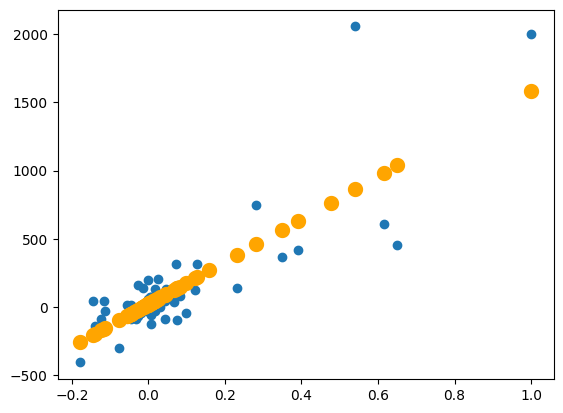

loss =  32006.262


In [85]:
from IPython.display import clear_output

epochs = 1000 # число эпох

w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

for i in range(epochs):

    y_pred = linear_regression(x)
    loss = mean_square(y_pred, y)

    loss.backward() # считаем градиенты

    with torch.no_grad():
      # делаем шаг градиентного спуска с lr = .05
      w -= 0.05 * w.grad
      b -= 0.05 * b.grad

      # обнуляем градиенты, чтобы на следующем шаге посчитать их с нуля,
      # а не сложить с предыдущими
      w.grad.zero_()
      b.grad.zero_()

    # рисуем картинки
    if (i+1) % 5 == 0:
        clear_output(True)
        plt.scatter(x.data.numpy(), y.data.numpy())
        plt.scatter(x.data.numpy(), y_pred.data.numpy(),
                    color='orange', linewidth=5)
        plt.show()

        print("loss = ", loss.data.numpy())
        if loss.data.numpy() < 0.5:
            print("Done!")
            break


In [86]:
y_pred

tensor([ 1.5837e+03,  6.0347e+01,  4.6759e+01,  6.0315e+01,  2.9868e+01,
        -4.3720e-01,  1.3985e+01,  1.1439e+01,  1.3394e+01,  4.3197e+01,
         2.7292e+01,  2.0503e+01,  2.5268e+01,  2.9497e+01,  8.6516e+02,
         9.8215e+02,  1.0375e+03,  7.6507e+02,  6.3243e+02,  4.5886e+02,
         5.6461e+02,  2.1873e+02,  2.6838e+02,  1.3938e+02,  1.3337e+02,
         1.8479e+01, -6.6362e+01, -2.3399e+01,  3.8393e+02,  1.3841e+02,
         8.6997e+01, -5.0787e+01,  9.0603e+01,  3.3731e+01,  1.7353e+01,
         1.9263e+01,  3.1214e+01, -9.9230e+01,  1.7629e+02, -1.9691e+02,
         5.9679e+01, -1.5642e+02,  2.1077e+01, -4.9217e+01,  2.5802e+01,
         1.2287e+01, -5.0129e-01,  3.2072e+01,  2.1280e+02, -2.4205e+00,
        -2.0667e+02,  2.0891e+01, -5.1071e+01,  2.6941e+01, -1.5209e+01,
        -9.6423e+00,  4.6245e+01,  1.4906e+02, -1.7225e+02, -5.7486e+01,
        -2.2572e+01,  2.7393e+01,  1.7273e+01,  5.1570e+00, -2.5799e+02,
        -1.6098e+02, -6.7271e+01, -3.0831e+01,  5.4

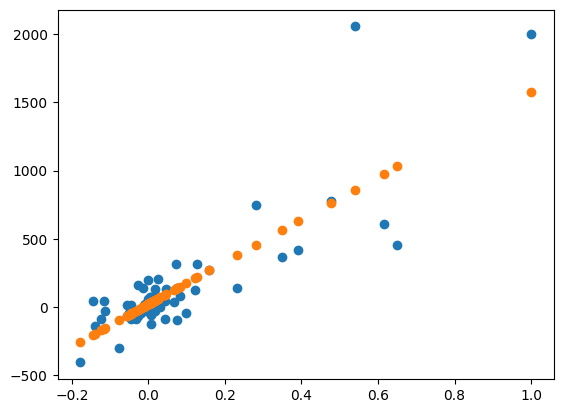

In [87]:
from IPython.display import clear_output

epochs = 100

w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

for i in range(epochs):
    y_pred = w * x + b
    loss = torch.mean((y - y_pred) ** 2)
    loss.backward()

    with torch.no_grad():
        w -= 0.5 * w.grad
        b -= 0.5 * b.grad

    w.grad.zero_()
    b.grad.zero_()

    if i % 5 == 0:
        clear_output(True)
        plt.scatter(x.numpy(), y.numpy())
        plt.scatter(x.numpy(), y_pred.detach().numpy())
        plt.show()



### Задание 6:

Решите задачу

$$
f(w) = \prod_{i,j} \ln(\ln(w_{ij} + 7) \to \min_{w}
$$

с помощью градиентного спуска. Выведите минимальное значение.

In [89]:
# ващ код  ¯\_(⊙︿⊙)_/¯
# w = torch.randn(2, 2, requires_grad=True)
w = torch.tensor([[5, 10], [1, 2]], requires_grad=True, dtype=torch.float32)

def f(w):
    return torch.prod(torch.log(torch.log(w + 7)))

epochs = 500

history = []

for i in range(epochs):
    loss = f(w)
    loss.backward()

    with torch.no_grad():
        w -= 0.001 * w.grad
        
        w.grad.zero_()

    # history.append(loss.item())

print(w)

tensor([[4.9900, 9.9948],
        [0.9775, 1.9825]], requires_grad=True)


В этом примере мы написали градиентный спуск руками. На парктике нам не придется это делать. К счастью, в PyTorch есть отдельный модуль, который отвечает за оптимизаторы. На него мы посмотрим ниже при обучении своей первой нейросети.

# 5. Менеджеры контекста

Поведением градиента сразу группы тензоров можно управлять с помощью специальных функций, которые вызываются через стандартную семантику питона `with foo():`, где `foo` — одна из трёх функций ниже:

- **Default Mode.** Стандартный режим работы pytorch, в котором управление градиентами происходит через `requires_grad`. Явно его нужно вызывать только внутри других контекстных менеджеров, чтобы временно снова активировать расчёт градиентов (что случается крайне редко) вызовом `torch.enable_grad()`.

- **No grad mode.** Данный режим используется когда блока кода нет необходимости вычислять градиенты, что занимает как вычислительные ресурсы, так и дополнительную память. Реализуется вызовом `torch.no_grad()`. Типичная ошибка -- забыть отключить вычисление градиентов при инференсе и забить всю оперативку ими.

- **Inference mode.**  Аналогично No grad mode отключает расчёт градиентов, но кроме того проводит дополнительные оптимизации, что делает вычисления внутри блока кода ещё быстрее. Однако, тензоры, созданные в таком блоке будет невозможно использовать совместно с тензорами, для которых расчёт градиента необходим. Реализуется вызовом `torch.inference_mode()`.

In [90]:
x = torch.rand(3, requires_grad=True)

with torch.no_grad():
    y = x + x

y.requires_grad

False

In [91]:
@torch.no_grad()
def foo(x):
    return x + 2

y = foo(x)
y.requires_grad

False

# 6. Моя первая нейросеть

Для того, чтобы разобраться как обучать нейросетки, нужно освоить три вещи:

1. Как обрабатывать поток данных и пихать его в сетку
2. Как сделать сетку
3. Как написать цикл обучения

## 6.1 Как формировать батчи и пихать их в сетку

С данными помогают работать две абстракции: `Dataset` и `DataLoader`.

`Dataset` умеет выдавать по индексу некоторый элемент и помогает итерироваться по данным. Чтобы работать с данными и применять к ним преобразования, например, аугментации, о которых вы узнаете позже — нужно создать свой класс унаследованный от `torch.utils.data.Dataset`.

У такого класса должно быть два метода:

* `__len__` — возвращает информацию о том, сколько объектов у нас в датасете
* `__getitem__` — возвращает семпл и таргет к нему

Теперь давайте напишем такой сами, в качестве датасета сгенерируем рандомные данные. В следующих семинарах мы обязательно попишем более сложные датасеты.

In [98]:
class RandomDataset(torch.utils.data.Dataset):
    """Our random dataset"""

    def __init__(self, x, y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # return {'sample': torch.tensor(x[idx, :], dtype=torch.float), 'target': y[idx]}
        return {'sample': torch.tensor(x[idx], dtype=torch.float), 'target': y[idx]}

In [99]:
x = np.random.rand(1000, 5)
y = np.random.rand(1000)

In [100]:
our_dataset = RandomDataset(x, y)

In [101]:
our_dataset.__getitem__(1)

{'sample': tensor([0.7659, 0.9249, 0.0129, 0.0165, 0.5346]),
 'target': np.float64(0.9469715444411556)}

`Dataset` умеет говорить сколько в выборке объектов и брать из неё очередной. Этого мало. Данные хочется как-то видоизменять. Для этого есть такая сущность как `DataLoader`.

Он принимает на вход класс унаследованный от `torch.utils.data.Dataset` и преобразовывает его.

In [103]:
dataloader = torch.utils.data.DataLoader(our_dataset, batch_size=4, shuffle=True)
dataloader

Здесь:
- `batch_size` — размер батча, на которые даталоадер будет делить данные перед каждой эпохой;
- `shuffle` — если `True`, то перед каждой эпохой и делением на батчи данные будут перемешаны. Shuffle обычно ставится `True` для обучающих данных, и `False` для тестовых.

Итерироваться по данным можно циклом.



In [104]:
for batch in dataloader:
    batch_x = batch['sample']
    batch_y = batch['target']
    break

print('Sample:', batch_x)
print('Target:', batch_y)

Sample: tensor([[0.3035, 0.3847, 0.7445, 0.2423, 0.3725],
        [0.7725, 0.4004, 0.5030, 0.6532, 0.9141],
        [0.2374, 0.4799, 0.2661, 0.7637, 0.5527],
        [0.8644, 0.2432, 0.4177, 0.7846, 0.4231]])
Target: tensor([0.3406, 0.5425, 0.3993, 0.4173], dtype=torch.float64)


Если бы мы написали метод в классе даталоадера чуть иначе:

```
    def __getitem__(self, idx):
        # Возвращаемый результат — (x, y), а не словарь!
        sample = torch.tensor(self.x[idx, :], dtype=torch.float)
        target = torch.tensor(self.y[idx], dtype=torch.float)
        return sample, target
```

мы бы возвращали tuple а не словарь и смогли бы итерироваться по объектам лоадера проще

```
for batch_x, batch_y in dataloader:
```

## 6.2 Нейронная сеть

Есть несколько способов задать нейросеть.

**Способ 1:** задать нейросеть в виде класса, который наследуется от абстрактного класса `torch.nn.Module`. В этот класс завёрнуто куча кода, который делает работу с параметрами нейросети на порядок удобнее.

Нам для задания нейросети достаточно определить у класса методы `__init__ `и `forward`.

В методе `__init__ ` обычно прописываются слои и артибуты сети, а в `forward` — то, как нейросеть будет обрабатывать данные, поданные ей на вход.

In [106]:
from torch import nn
import torch.nn.functional as F

class NeuralNet(nn.Module):
    def __init__(self):

      '''
        Конструктор блока. Здесь обычно создают обучаемые параметры и сохраняют переменные,
            определяющие глобальное состояние слоя, а так же гиперпараметры
        Блок, может содержать в себе подблоки, которые также были отнаследованы от базового класса torch.nn.Module
      '''
      # Необходимо вызвать конструктор базового класса для корректной работы блока
      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(5, 3),
          nn.ReLU(),
          nn.Linear(3, 1)
        )

    def forward(self, x):
        '''
        Функция, реализующая прямой проход через слой. В процессе вычислений создаётся граф вычислений
            сквозь который выполняется автоматическое дифференцирование.
        '''
        return self.model(x)

Модуль `nn` содержит в себе реализацию большинства слоев, а модуль `nn.functional`—  функций активаций.

In [107]:
model = NeuralNet()  # завели себе нейросеть
model(batch_x)   # получили предсказания модели

tensor([[0.0731],
        [0.1903],
        [0.1574],
        [0.1696]], grad_fn=<AddmmBackward0>)

__Способ 2:__ можно собрать модель с помощью класса `Sequential`. В его рамках сбор модели будет выглядить как строительство башни из конструктора LEGO. Модель описывается последовательно. Мы как бы создаём коробочку `model` и постепенно добавляем туда детальки нашей сетки.

In [108]:
model = nn.Sequential()                 # создаем пустую модель, в которую будем добавлять слои
model.add_module('l1', nn.Linear(5, 3)) # добавили слой с 5-ю нейронами на вход и 3-мя на выход
model.add_module('l2', nn.ReLU())       # добавили функцию активации
model.add_module('l3', nn.Linear(3, 1)) # добавили слой с 3-мя нейронами на вход и 5-ю на выход

In [109]:
model(batch_x) # получили предсказания модели

tensor([[-0.2115],
        [-0.2163],
        [-0.2244],
        [-0.1906]], grad_fn=<AddmmBackward0>)

__Способ 3:__ описать модель функционально, в явном виде прописав какие аргументы идут на вход какому слою.

In [110]:
h = nn.Linear(5, 3)(batch_x)
h = nn.ReLU()(h)
out = nn.Linear(3, 1)(h)
out

tensor([[-0.4561],
        [-0.5127],
        [-0.4961],
        [-0.5158]], grad_fn=<AddmmBackward0>)

Обычно модель объявляют в виде класса, а второй и третий способ используют, чтобы в в более явном виде задать разные вычислительные блоки.

## 6.3 Цикл для обучения модели

Осталось научиться писать циклы для обучения. Давайте подгрузим настоящие данные, соберём модель и обучим её.

In [111]:
from torchvision.datasets import MNIST
from torch.utils.data import Dataset, DataLoader

# внутри модуля transforms есть много полезных преобразований
# пока что нам из него понадобится только T.ToTensor()
# для конвертации картинки в тензор
import torchvision.transforms as T

Не будем выпендриваться и обучим нашу первую нейросеть на [классическом датасете из рукопистных цифр MNIST.](http://yann.lecun.com/exdb/mnist/)

In [113]:
# подгружаем датасет из библиотеки
train_set = MNIST('.MNIST', transform=T.ToTensor(), train=True, download=True)
test_set = MNIST('.MNIST', transform=T.ToTensor(), train=False, download=True)

Давайте нарисуем несколько изображений.

In [120]:
train_set[100][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

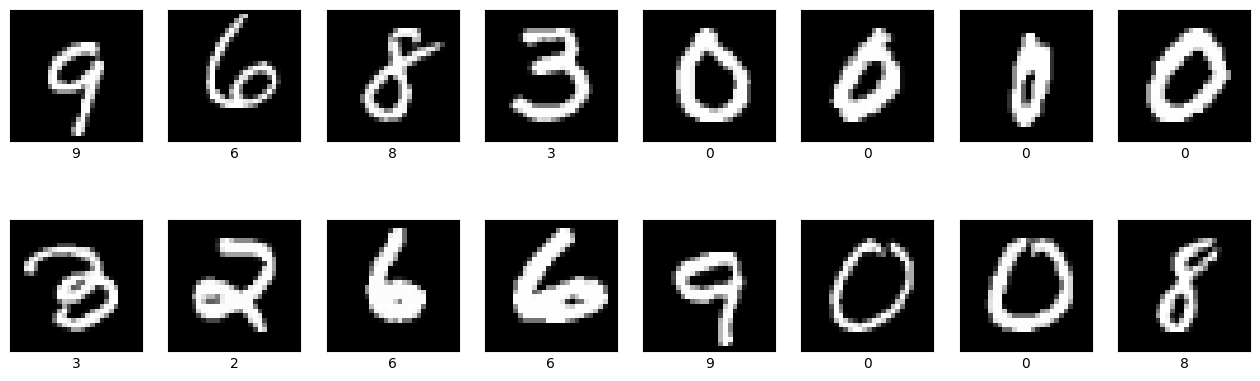

In [114]:
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols, 2.5 * rows))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(train_set))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(train_set[random_index][0].squeeze(0).numpy().reshape([28, 28]), cmap = 'gray')
        ax.set_xlabel(train_set[random_index][1])
plt.show()

Каждая картинка это матрица из чисел. Если число большое - пиксель яркий. Если маленькое - тёмный.

In [123]:
train_set[5][0].shape

torch.Size([1, 28, 28])

Будем прогнозировать тип картинки по её пикселям. Подготовим данные с помощью `DataLoader`. Пока что попробуем настроить его максимально просто. В будущем мы увидим с вами другую магию, на которую способна эта абстракция.

### Задание 7:

Напишите `DataLoader` для тренировочной и тестовой выборок. Попробуйте проитерироваться по нескольким его первым объектам с помощью цикла.

В обучающей выборке данные должны перемешиваться каждую эпоху. Размер батча поставьте равным 64. В тестовой выборке данные перемешивать не надо.

In [124]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

In [125]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])


In [ ]:
# берем датасет, перемешиваем его и формируем батчи
# train_loader = torch.utils.data.DataLoader(
#     train_set, batch_size=64, shuffle=True
# )

# test_loader = torch.utils.data.DataLoader(
#     test_set, batch_size=64, shuffle=False
# )

### Задание 8:

Напишите  двухслойную полносвязную нейросеть. Выходной слой должен состоять из $10$ нейронов.

In [131]:
class NeuralNet(nn.Module):
    def __init__(self, in_features, num_classes, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.LeakyReLU(0.1),
            nn.Linear(in_features=hidden_size, out_features=num_classes),
            # nn.LogSoftmax()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
class NeuralNet(nn.Module):
    def __init__(self, in_features, num_classes, hidden_size):
        super().__init__()
        self.model = nn.Sequential(

            # ващ код  ¯\_(⊙︿⊙)_/¯
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=hidden_size, bias=False),
            nn.LeakyReLU(0.1),
            nn.Linear(in_features=hidden_size, out_features=num_classes),
            # nn.LogSoftmax(), # в функцию потерь пойдут логиты а не SoftMax для устойчивости вычислений
        )

    def forward(self, x):
        return self.model(x)

In [132]:
model = NeuralNet(28**2, 10, 20)

Веса моделей хранятся в виде матриц и выглядят так:

In [133]:
[x for x in model.named_parameters()]

[('model.0.weight',
  Parameter containing:
  tensor([[-0.0087,  0.0282,  0.0095,  ..., -0.0131,  0.0165,  0.0110],
          [-0.0329, -0.0228, -0.0142,  ...,  0.0126,  0.0353,  0.0192],
          [ 0.0288, -0.0252,  0.0263,  ...,  0.0231,  0.0087,  0.0017],
          ...,
          [-0.0324,  0.0299,  0.0160,  ..., -0.0154,  0.0287,  0.0315],
          [ 0.0119,  0.0195,  0.0095,  ..., -0.0055,  0.0102,  0.0147],
          [ 0.0172,  0.0202,  0.0074,  ...,  0.0265, -0.0318,  0.0217]],
         requires_grad=True)),
 ('model.0.bias',
  Parameter containing:
  tensor([ 0.0333,  0.0026,  0.0295, -0.0079, -0.0069,  0.0031, -0.0222,  0.0021,
          -0.0261,  0.0261,  0.0342,  0.0235, -0.0334,  0.0015, -0.0254,  0.0113,
           0.0243,  0.0078, -0.0063, -0.0320], requires_grad=True)),
 ('model.2.weight',
  Parameter containing:
  tensor([[ 9.9477e-02, -1.2964e-01,  1.1033e-01, -1.2592e-01,  1.5122e-01,
            2.0786e-01, -5.8011e-02,  2.0030e-01,  6.2678e-02, -6.9282e-02,
      

Объявляем модель и оптимизатор.

In [134]:
IMG_SIZE = 28
NUM_CLASSES = 10
HIDDEN_SIZE = 64
NUM_EPOCHS = 10

# объявим нейросеть и пошлём её на GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features=IMG_SIZE ** 2, num_classes=NUM_CLASSES, hidden_size=HIDDEN_SIZE).to(device)

# чтобы не писать самим SGD, подгрузим готовый оптимизатор
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# функция потерь
criterion = nn.CrossEntropyLoss() # работает с логитом!


Осталось всё это дело обучить. Для этого нам придётся написать цикл

In [135]:
from tqdm.notebook import tqdm

# NUM_EPOCHS раз подряд пройдемся по всем батчам из трейна
for epoch in range(NUM_EPOCHS):

    # переключили модель в режим трэйна (важно для батчнорма и дропаута)
    # как минимум эти два слоя при обучении и прогнозировании работают по-разному
    model.train()

    # берем батч из трейн лоадера
    for images, labels in tqdm(train_loader):

        # отправляем тензоры на девайс к сетке
        images = images.to(device)
        labels = labels.to(device)

        ### Пишем самые важные 5 строк
        # зануляем старые градиенты, иначе они сложатся
        optimizer.zero_grad()

        # вызываем модель
        logits = model(torch.flatten(images, start_dim=1))
        # (batch_size, x, num_classes) - размерность

        # считаем функцию потерь
        loss = criterion(logits, labels)

        # считаем градиенты обратным проходом
        loss.backward()

        # обновляем параметры сети (шаг спуска)
        optimizer.step()

    if epoch % 2 == 0:
        mean_val_loss = [] # сюда будем складывать средний лосс по батчам
        val_accuracy = []

        # переключили модель в режим инференса (важно для дропаута и батчнорма)
        model.eval()

        # берем батч из вал лоадера для валидации
        for images, labels in tqdm(test_loader, desc='Validating'):
            images = images.to(device)
            labels = labels.to(device)

            # мы считаем качество, поэтому мы запрещаем фреймворку считать
            # градиенты по параметрам, это лишнее, они нам не нужны
            with torch.no_grad():
                # делаем предсказания
                logits = model(torch.flatten(images, start_dim=1))

                # считаем ошибку на валидации
                loss = criterion(logits, labels)

                mean_val_loss.append(loss.cpu().item()) # добавляем в массив
                val_accuracy.extend((torch.argmax(logits, dim=-1) == labels).cpu().numpy().tolist())

        # выводим статистику
        print('Epoch: {epoch}, loss: {loss}, accuracy: {accuracy}'.format(
                epoch=epoch, loss=np.mean(mean_val_loss), accuracy=np.mean(val_accuracy)
        ))


  0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 0.24124519418403031, accuracy: 0.9287


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 8, loss: 0.08282914850786684, accuracy: 0.9753


  0%|          | 0/938 [00:00<?, ?it/s]

Кажется, что всё работает. Но есть проблемы:

- Мы не нарисовали ни одного графика. Метрики хорошо бы куда-то залоггировать.
- Цикл громоздкий, хорошо бы разбить его на отдельные функции для обучения и валидации. Мы будем его постоянно переписывать и дополнять. Рано или поздно код станет нечитаемым.
- Проблема воспроизводимости. Обучение сильно меняется от запуска к запуску. Возможно, вы один раз получите крутой результат, а потом не сможете его никогда воспроизвести. Это плохо. Чтобы такого не было, надо зафиксировать `seed`.

## 7. Итоговый пайплайн

Для начала постараемся сделать обучение независимым от очередности запуска, воспользуемся советами из официальной статьи [Reproducibilty PyTorch.](https://docs.pytorch.org/docs/stable/notes/randomness.html) Нам необходимо:

- Зафиксировать сид cpu
- Зафиксировать сид gpu
- Зафиксировать сид numpy
- Зафиксировать сид стандартного random

In [136]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # если хочется воспроизводимость на 1000%, надо настроить эту штуку
    # torch.use_deterministic_algorithms(True)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

Эти функции с сидами можно просто копировать в начало своих тетрадок и добавлять в DataLoader.

Теперь напишем функции для обучения.

In [137]:
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})

def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [139]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    """Одна эпоха обучения"""
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images, labels in tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(torch.flatten(images, start_dim=1))
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.shape[0]
        train_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, test_loader, tqdm_desc):
    """Прогнозы на валидации"""

    test_loss, test_accuracy = 0.0, 0.0
    model.eval()
    for images, labels in tqdm(test_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(torch.flatten(images, start_dim=1))
        loss = criterion(logits, labels)

        test_loss += loss.item() * images.shape[0]
        test_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy /= len(test_loader.dataset)
    return test_loss, test_accuracy


def train(model, optimizer, criterion, train_loader, test_loader, num_epochs, scheduler=None):
    """Обучение модели"""

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        val_loss, val_accuracy = validation_epoch(
            model, criterion, test_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # функция для смены lr по расписанию
        if scheduler is not None:
            scheduler.step()

        plot_losses(train_losses, val_losses, train_accuracies, val_accuracies)

In [140]:
g = set_global_seed(42)

train_set = MNIST('.MNIST', transform=T.ToTensor(), train=True, download=True)
val_set = MNIST('.MNIST', transform=T.ToTensor(), train=False, download=True)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size     = 256,
    shuffle        = True,
    num_workers    = 0,
    worker_init_fn = seed_worker,
    generator      = g
)

test_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size    = 4096,
    shuffle       = False,
    num_workers   = 0
)

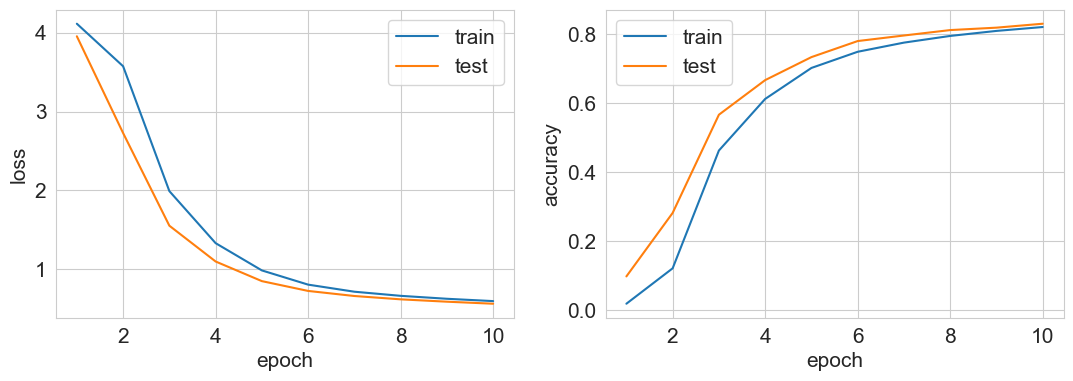

In [141]:
IMG_SIZE = 28
NUM_CLASSES = 10
HIDDEN_SIZE = 64
NUM_EPOCH = 10
LR = 0.01

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(IMG_SIZE**2, HIDDEN_SIZE, NUM_CLASSES).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

train(model, optimizer, criterion, train_loader, test_loader, NUM_EPOCH)

Добавим в обучение смену LR по расписанию.

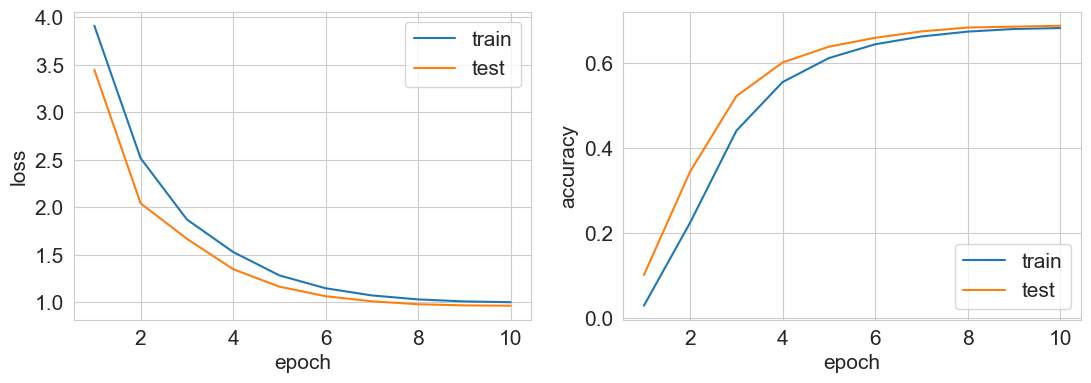

In [142]:
IMG_SIZE = 28
NUM_CLASSES = 10
HIDDEN_SIZE = 64
NUM_EPOCH = 10
LR = 0.01

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(IMG_SIZE**2, HIDDEN_SIZE, NUM_CLASSES).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCH)
criterion = nn.CrossEntropyLoss()

train(model, optimizer, criterion, train_loader, test_loader, NUM_EPOCH, scheduler=scheduler)

Теперь воспроизводимость и удобство нам обеспечены. Тем не менее, в этом коде всё ещё много чего не хватает.

Во-первых, логгировать эксперименты можно куда удобнее. Во-вторых, хорошо бы делать чекпойнты и сохранять лучшие версии модели по мере обучения, чтобы впоследствии их не потерять. На логгирование мы посмотрим ниже, а чекпойнты вам предстоит научиться делать в домашке.

## 8. Логгирование экспериментов

Вместо того, чтобы каждый раз самим рисовать графики в `matplotlib`, можно красиво трекать метрики в полуавтоматическом режиме в [WandB.](https://docs.wandb.ai/)

**Зачем это надо:**

Обычно, при обучении моделей надо ставить большое количество экспериментов. Это делает команда из кучи людей. Очень удобно залоггировать всё в одно место и дальше сравнивать разные запуски моделей между собой. Для этого есть довольно много разных сервисов. На наш взгляд WandB один из самых удачных.

Для этого регистрируемся на сайте, устанавливаем и логинимся. Пробуем запустить [туториал со стартовой тетрадкой.](https://docs.wandb.ai/tutorials/pytorch/)

> Официально с 12 сентября 2024 года, данная библиотека может не работать на территории РФ, поэтому расчехляем VPN не только для ютуба.

In [ ]:
!pip install wandb -qU

In [ ]:
import wandb
wandb.login()

Функции в переписанном варианте будут выглядеть вот так:

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images, labels in tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(torch.flatten(images, start_dim=1))
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.shape[0]
        train_accuracy += (logits.argmax(dim=1) == labels).sum().item()

        metrics = {
            "batch-train/loss": loss.item()
        }
        wandb.log(metrics)

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, test_loader, tqdm_desc):
    test_loss, test_accuracy = 0.0, 0.0
    model.eval()
    for images, labels in tqdm(test_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(torch.flatten(images, start_dim=1))
        loss = criterion(logits, labels)

        test_loss += loss.item() * images.shape[0]
        test_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy /= len(test_loader.dataset)
    return test_loss, test_accuracy

def train(model, optimizer, criterion, train_loader, test_loader, num_epochs, scheduler=None):

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        val_loss, val_accuracy = validation_epoch(
            model, criterion, test_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        metrics = {
            "train/loss": train_loss / len(train_loader.dataset),
            "train/accuracy": train_accuracy / len(train_loader.dataset),
            "val/loss": val_loss,
            "val/accuracy": val_accuracy
        }
        wandb.log(metrics)

In [ ]:
IMG_SIZE = 28
NUM_CLASSES = 10
HIDDEN_SIZE = 64
NUM_EPOCH = 10
LR = 0.01

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(IMG_SIZE**2, HIDDEN_SIZE, NUM_CLASSES).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCH)
criterion = nn.CrossEntropyLoss()

In [ ]:
wandb.init(
    project="my-first-nn-project",
    name='FCN + CosineAnnealingLR',
    config={
        "architecture": 'CNN',
        "learning_rate": LR,
        "scheduler": 'None',
        "epochs":  NUM_EPOCH,
        "dataset": "MNIST",
        "optimizer": 'SGD + CosineAnnealingLR',
    }
)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, scheduler=scheduler)

wandb.finish()